<a href="https://colab.research.google.com/github/BADIAMOHAMEDAYMANE/Animal-Classification/blob/main/ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Installation des dépendances**

In [ ]:
!pip install torch torchvision matplotlib streamlit pyngrok pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 132.0 MB/s eta 0:00:00


# **2. Imports**

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# **3. Chargement du dataset CIFAR-10**

In [5]:
transform = transforms.Compose([
    # Supprimer le Resize(224) — garder le 32×32 natif
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # 3 canaux RGB
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128,      # 64 → 128
    shuffle=True,
    num_workers=2,                 # parallélise le chargement
    pin_memory=True                # accélère le transfert vers GPU
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

classes = trainset.classes
print(classes)

100%|██████████| 170M/170M [01:24<00:00, 2.02MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# **4. Visualisation des données**

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


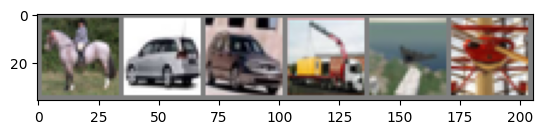

['horse', 'automobile', 'automobile', 'truck', 'airplane', 'airplane']


In [6]:
import matplotlib.pyplot as plt

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:6]))
print([classes[i] for i in labels[:6]])

# **5. Architecture du modèle CNN**

In [7]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            # Bloc 1 — 32×32 → 16×16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Bloc 2 — 16×16 → 8×8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Bloc 3 — 8×8 → 4×4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128 * 4 * 4, 256),  # 128 filtres × 4×4
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")
model = CNN(num_classes=10).to(device)

Device utilisé : cpu


# **6. Entrainement**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)  # step_size 1 → 5

epochs = 20
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()
    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

# **7. Evaluation**

In [2]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

NameError: name 'model' is not defined

# **8. Courbe de loss**

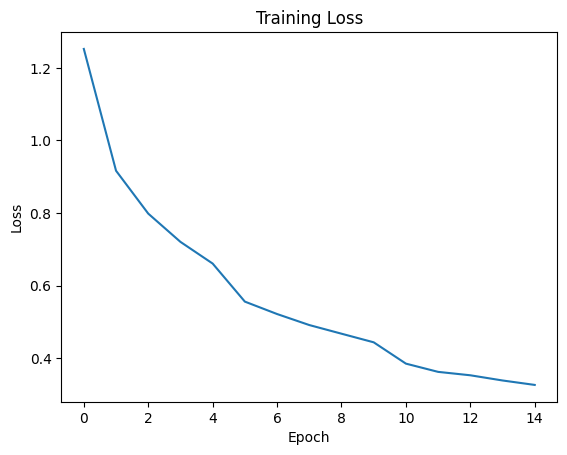

In [40]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# **9. Sauvegarde du modèle**

In [41]:
torch.save(model.state_dict(), "model.pth")
print("Modèle sauvegardé !")

Modèle sauvegardé !


# **10. Fonction de prédiction**

In [42]:
from PIL import Image

def predict_image(image):
    """Accepte une PIL Image OU un tensor déjà normalisé."""

    if isinstance(image, torch.Tensor):
        # Tensor déjà normalisé → ajouter batch dimension directement
        img_tensor = image.unsqueeze(0).to(device)
    else:
        # PIL Image → appliquer le transform complet
        transform_test = transforms.Compose([
            transforms.Resize((32, 32)),          # ✓ adapté au CNN 32×32
            transforms.ToTensor(),
            transforms.Normalize(
                (0.5, 0.5, 0.5),                  # ✓ 3 canaux RGB
                (0.5, 0.5, 0.5)
            )
        ])
        img_tensor = transform_test(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        _, pred = torch.max(outputs, 1)

    return classes[pred.item()]

# **11. Test sur une image**

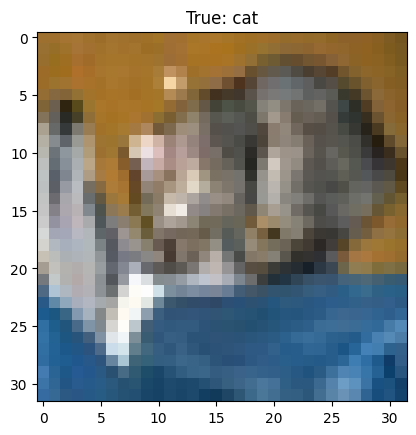

Prediction: cat


In [43]:
img, label = testset[0]

plt.imshow(np.transpose(img.numpy(), (1, 2, 0)) * 0.5 + 0.5)
plt.title(f"True: {classes[label]}")
plt.show()

print("Prediction:", predict_image(img))

# **12. Application Streamlit**

In [44]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),                  # ✅ Dropout ajouté — identique au notebook
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)            # ✅ view() identique au notebook
        return self.classifier(x)

model = CNN(num_classes=10)
model.load_state_dict(torch.load("model.pth", map_location="cpu"))
model.eval()

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # ✅ 3 canaux RGB
])

st.title("🖼️ CIFAR-10 CNN Classifier")
file = st.file_uploader("Upload an image", type=["jpg", "png"])

if file:
    image = Image.open(file).convert("RGB")
    st.image(image)
    if st.button("Predict"):
        img = transform(image).unsqueeze(0)
        with torch.no_grad():
            output = model(img)
            _, pred = torch.max(output, 1)
        st.success(f"Prediction: **{classes[pred.item()]}**")

Overwriting app.py
